In [5]:
import shap
import numpy as np
from shap.datasets import iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Load the data:

X,y= iris(display=True)

In [3]:
X

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [4]:
y

['setosa',
 'setosa',
 'setosa',
 'setosa',
 'setosa',
 'setosa',
 'setosa',
 'setosa',
 'setosa',
 'setosa',
 'setosa',
 'setosa',
 'setosa',
 'setosa',
 'setosa',
 'setosa',
 'setosa',
 'setosa',
 'setosa',
 'setosa',
 'setosa',
 'setosa',
 'setosa',
 'setosa',
 'setosa',
 'setosa',
 'setosa',
 'setosa',
 'setosa',
 'setosa',
 'setosa',
 'setosa',
 'setosa',
 'setosa',
 'setosa',
 'setosa',
 'setosa',
 'setosa',
 'setosa',
 'setosa',
 'setosa',
 'setosa',
 'setosa',
 'setosa',
 'setosa',
 'setosa',
 'setosa',
 'setosa',
 'setosa',
 'setosa',
 'versicolor',
 'versicolor',
 'versicolor',
 'versicolor',
 'versicolor',
 'versicolor',
 'versicolor',
 'versicolor',
 'versicolor',
 'versicolor',
 'versicolor',
 'versicolor',
 'versicolor',
 'versicolor',
 'versicolor',
 'versicolor',
 'versicolor',
 'versicolor',
 'versicolor',
 'versicolor',
 'versicolor',
 'versicolor',
 'versicolor',
 'versicolor',
 'versicolor',
 'versicolor',
 'versicolor',
 'versicolor',
 'versicolor',
 'versicolor',


In [6]:
y=pd.Series(y)
y

0         setosa
1         setosa
2         setosa
3         setosa
4         setosa
         ...    
145    virginica
146    virginica
147    virginica
148    virginica
149    virginica
Length: 150, dtype: str

In [7]:
# spliting the data:

x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,stratify=y)

In [8]:
x_train.shape

(120, 4)

In [9]:
y_train.shape

(120,)

In [10]:
x_test.shape

(30, 4)

In [12]:
y_train.value_counts()

virginica     40
setosa        40
versicolor    40
Name: count, dtype: int64

In [13]:
# Distribution of target:

y_train.value_counts(normalize=True)

virginica     0.333333
setosa        0.333333
versicolor    0.333333
Name: proportion, dtype: float64

In [14]:
y_test.value_counts()

versicolor    10
virginica     10
setosa        10
Name: count, dtype: int64

In [15]:
y_test.value_counts(normalize=True)

versicolor    0.333333
virginica     0.333333
setosa        0.333333
Name: proportion, dtype: float64

In [16]:
# Encode the target:

l=LabelEncoder()

y_train=l.fit_transform(y_train)
y_test=l.transform(y_test)

In [17]:
y_train

array([2, 0, 2, 2, 2, 1, 0, 2, 0, 2, 0, 1, 1, 1, 2, 1, 0, 0, 2, 0, 1, 0,
       1, 1, 2, 0, 2, 2, 2, 2, 0, 2, 0, 2, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0,
       0, 2, 2, 0, 0, 2, 0, 1, 2, 2, 2, 1, 0, 0, 2, 2, 2, 0, 1, 2, 1, 1,
       1, 0, 2, 2, 0, 1, 0, 2, 1, 0, 0, 1, 1, 1, 2, 0, 0, 2, 0, 0, 2, 0,
       2, 2, 2, 2, 2, 1, 0, 0, 1, 1, 1, 0, 0, 1, 2, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 0, 2, 2, 1, 2, 1])

In [32]:
# Fit model data:

rf=RandomForestClassifier(random_state=42,max_depth=1,n_estimators=10)
rf.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",10
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: 

In [33]:
# Prediction:

y_pred=rf.predict(x_test)


In [34]:
accuracy_score(y_test,y_pred)

0.9666666666666667

In [41]:
l.classes_

array(['setosa', 'versicolor', 'virginica'], dtype=object)

In [35]:
explainer= shap.TreeExplainer(model=rf,data=x_train,model_output='probability')

Background dataset has 120 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=120 when initializing the masker.


In [38]:
# These are the base value of my model. I have 3 classes.So i get probability value for each class.x_train 
explainer.expected_value

array([0.32402057, 0.33593544, 0.34004399])

In [ ]:
# Let's calculate manually

rf.predict_proba(x_train).mean(axis=0)

# This values are slightly different because explainer pass 100 random value from x train, however we passed all the data.

array([0.32951083, 0.33534315, 0.33514603])

In [42]:
# Calculate shapley value:

shap_values=explainer(x_test,y_test)
shap_values


.values =
array([[[ 0.08118518, -0.03286887, -0.04831631],
        [ 0.        ,  0.        ,  0.        ],
        [-0.052     ,  0.05049359,  0.00150641],
        [-0.132     ,  0.06207908,  0.06992092]],

       [[-0.09243957,  0.04500311,  0.04743647],
        [ 0.        ,  0.        ,  0.        ],
        [-0.09088889, -0.00436752,  0.09525641],
        [-0.132     ,  0.06207908,  0.06992092]],

       [[ 0.08118518, -0.03286887, -0.04831631],
        [ 0.        ,  0.        ,  0.        ],
        [-0.052     ,  0.05049359,  0.00150641],
        [-0.132     ,  0.06207908,  0.06992092]],

       [[ 0.16412169, -0.08048792, -0.08363378],
        [ 0.        ,  0.        ,  0.        ],
        [ 0.148     , -0.04266881, -0.1053312 ],
        [ 0.268     , -0.12603934, -0.14196066]],

       [[ 0.16412169, -0.08048792, -0.08363378],
        [ 0.        ,  0.        ,  0.        ],
        [ 0.148     , -0.04266881, -0.1053312 ],
        [ 0.268     , -0.12603934, -0.14196066]],



In [46]:
x_test.head(2)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
90,5.5,2.6,4.4,1.2
145,6.7,3.0,5.2,2.3


In [47]:
x_test.iloc[0]

sepal length (cm)    5.5
sepal width (cm)     2.6
petal length (cm)    4.4
petal width (cm)     1.2
Name: 90, dtype: float64

In [ ]:
type(x_test.iloc[0])

# We have to pass data frame inside explainer.

pandas.Series

In [49]:
type(x_test.iloc[0:1,:])

pandas.DataFrame

In [51]:
# Let's make prediction for a single row:

test_case = x_test.iloc[0:1,:]

test_case

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
90,5.5,2.6,4.4,1.2


In [52]:
prediction = rf.predict(test_case)

prediction_prob = rf.predict_proba(test_case)

In [53]:
prediction

array([1])

In [54]:
prediction_prob

array([[0.22120575, 0.41563925, 0.36315501]])

In [55]:

l.inverse_transform(prediction)

array(['versicolor'], dtype=object)

In [56]:
shap_values = explainer(x_test.iloc[0:1,:])

In [ ]:
shap_values.shape

# 1- row
# 4- feature
# 3- classes

(1, 4, 3)

In [58]:
shap_values

.values =
array([[[ 0.08118518, -0.03286887, -0.04831631],
        [ 0.        ,  0.        ,  0.        ],
        [-0.052     ,  0.05049359,  0.00150641],
        [-0.132     ,  0.06207908,  0.06992092]]])

.base_values =
array([[0.32402057, 0.33593544, 0.34004399]])

.data =
array([[5.5, 2.6, 4.4, 1.2]])

In [59]:
shap_values.base_values

array([[0.32402057, 0.33593544, 0.34004399]])

In [60]:
explainer.expected_value

array([0.32402057, 0.33593544, 0.34004399])

In [64]:
shap_values[0,:,0]

.values =
array([ 0.08118518,  0.        , -0.052     , -0.132     ])

.base_values =
np.float64(0.324020566551189)

.data =
array([5.5, 2.6, 4.4, 1.2])

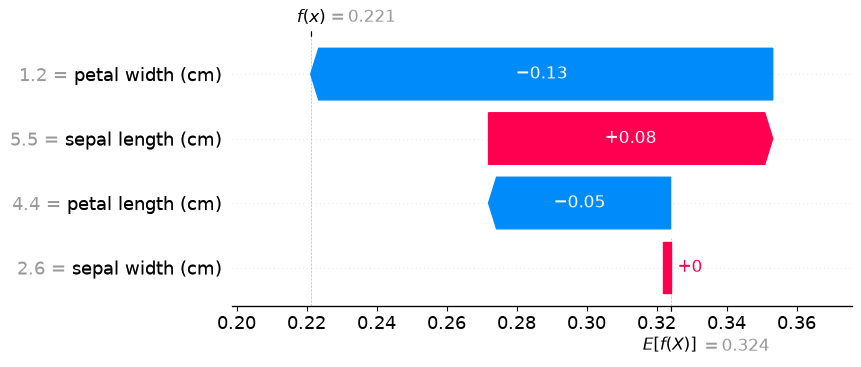

In [61]:
shap.waterfall_plot(shap_values[0,:,0])

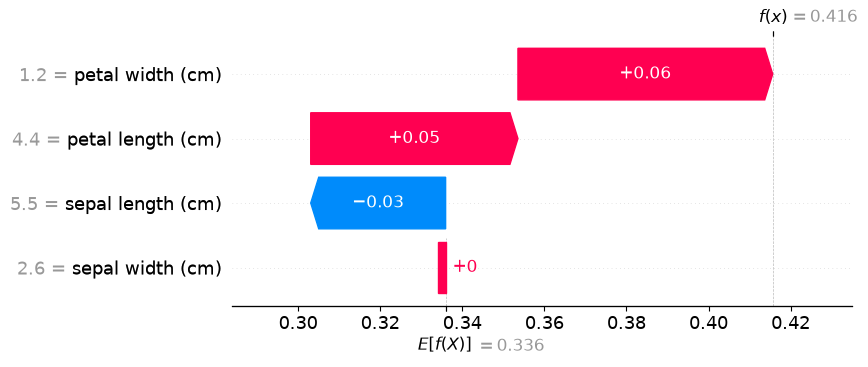

In [62]:
shap.waterfall_plot(shap_values[0,:,1])

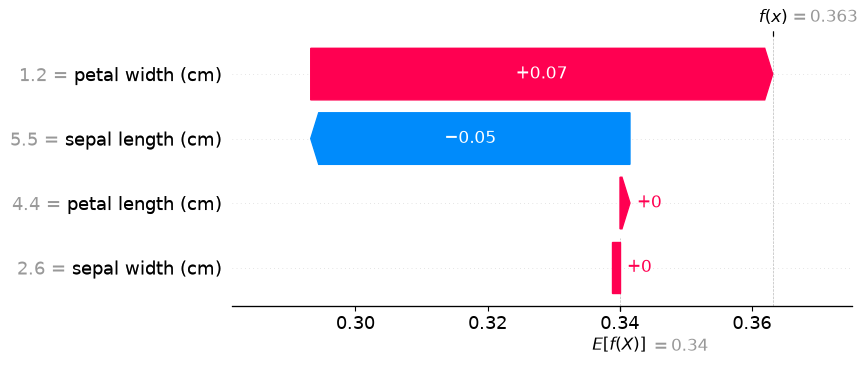

In [63]:
shap.waterfall_plot(shap_values[0,:,2])

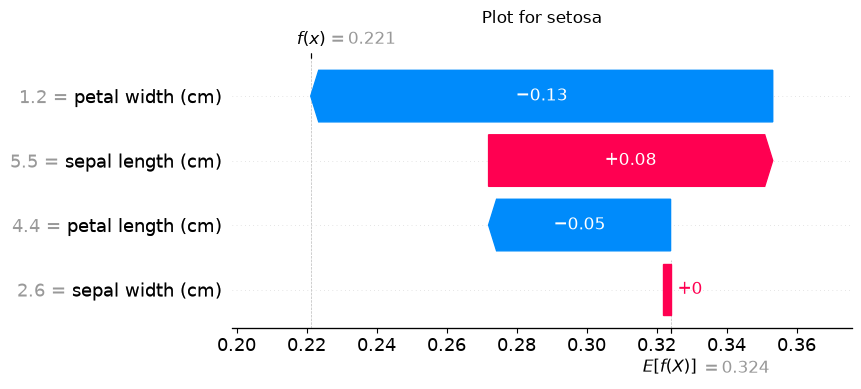

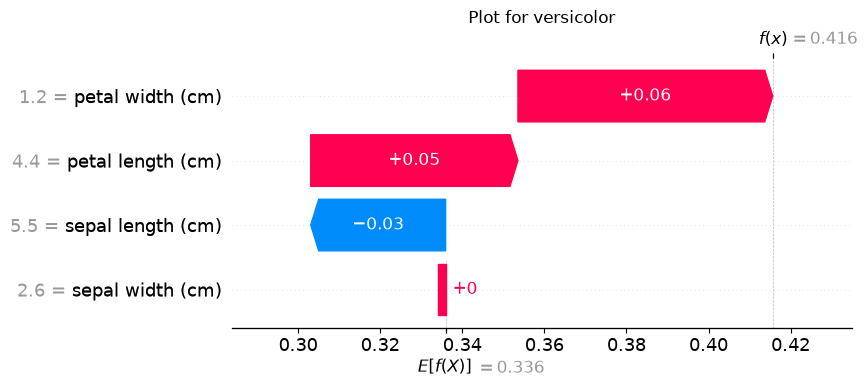

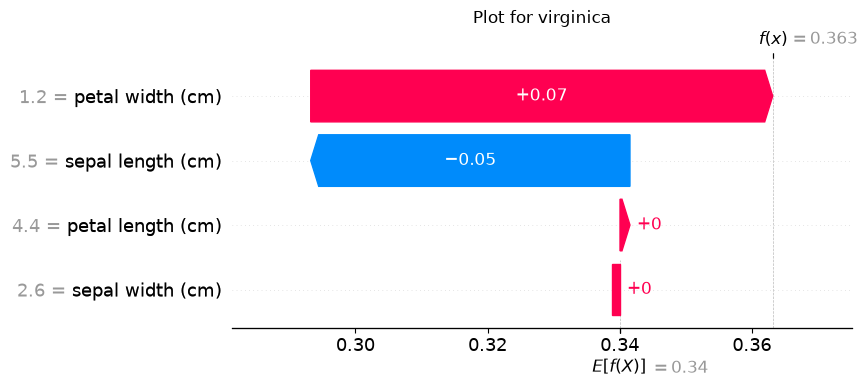

In [65]:
for i in range(len(l.classes_)):
    plt.title(f"Plot for {l.classes_[i]}")
    shap.waterfall_plot(shap_values[0,:,i])
    print("\n\n")